In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

## d1=installment payments
## d2=bureau_balance
## d3=credit card balance
## d4=previous application
## d5=bureau
## d6=pos cash balance

In [2]:
df=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\application_train.csv")
d1=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\installments_payments.csv")
d2=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\bureau_balance.csv")
d3=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\credit_card_balance.csv")
d4=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\previous_application.csv")
d5=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\bureau.csv")
d6=pd.read_csv(r"D:\PRCP-1006-HomeLoanDef\Data\POS_CASH_balance.csv")

In [3]:
data={
    "target dataset":df,
    "installment payments":d1,
    "bureau_balance":d2,
    "credit card balance":d3,
    "previous application":d4,
    "bureau":d5,
    "pos cash balance":d6
}

In [4]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [5]:
for name,d in data.items():
    shape=d.shape
    print("shape:",name,":",shape)

shape: target dataset : (307511, 122)
shape: installment payments : (13605401, 8)
shape: bureau_balance : (27299925, 3)
shape: credit card balance : (3840312, 23)
shape: previous application : (1670214, 37)
shape: bureau : (1716428, 17)
shape: pos cash balance : (10001358, 8)


In [6]:
for name,d in data.items():
    info=d.info()
    print("info",name,":",info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
info target dataset : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB
info installment payments : None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64

In [7]:
for name,d in data.items():
    null=d.isnull().sum()
    print("null_values:",name,":",null)

null_values: target dataset : SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64
null_values: installment payments : SK_ID_PREV                   0
SK_ID_CURR                   0
NUM_INSTALMENT_VERSION       0
NUM_INSTALMENT_NUMBER        0
DAYS_INSTALMENT              0
DAYS_ENTRY_PAYMENT        2905
AMT_INSTALMENT               0
AMT_PAYMENT               2905
dtype: int64
null_values: bureau_balance : SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64
null_values: credit card balance : SK_ID_PREV                         0
SK_ID_CURR                         0
MONTHS_BALANCE                     0
AM

## aggregating and merging the datasets

In [8]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [9]:
d1.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION',
       'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT',
       'AMT_INSTALMENT', 'AMT_PAYMENT'],
      dtype='object')

In [10]:
ag1=d1.groupby("SK_ID_CURR").agg({
       'DAYS_ENTRY_PAYMENT':"mean",
       'AMT_INSTALMENT':"mean",
       'AMT_PAYMENT':"sum"
})

In [11]:
d3.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='object')

In [12]:
ag3=d3.groupby('SK_ID_CURR').agg({
     'AMT_BALANCE':"mean",
     'AMT_CREDIT_LIMIT_ACTUAL':"mean",
     'AMT_PAYMENT_CURRENT':"mean"
})

In [13]:
d4.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

In [14]:
ag4=d4.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION':'mean', 
    'AMT_CREDIT':'mean',
    'AMT_DOWN_PAYMENT':'mean',
    'CNT_PAYMENT':'mean'
    })

In [15]:
d2.columns

Index(['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS'], dtype='object')

In [16]:
d2['STATUS'] = d2['STATUS'].replace({
'C':int(0),
'X':int(0)
})

In [17]:
ag2 = d2.groupby('SK_ID_BUREAU').agg({
'MONTHS_BALANCE':"min",
'STATUS':'count'
})

In [18]:
d5=d5.merge(ag2,on='SK_ID_BUREAU',how='left')

In [19]:
d5.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY', 'MONTHS_BALANCE', 'STATUS'],
      dtype='object')

In [20]:
ag5=d5.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT':'mean',
    'CREDIT_DAY_OVERDUE':'max',
    'AMT_CREDIT_SUM':'mean', 
    'AMT_CREDIT_SUM_OVERDUE':'max',
    'AMT_CREDIT_SUM_DEBT':'sum',
     'AMT_ANNUITY':'mean',
    'MONTHS_BALANCE':'min',
     'STATUS':'count'
    })

In [21]:
d6.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
       'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='object')

In [22]:
ag6=d6.groupby('SK_ID_CURR').agg({
     'CNT_INSTALMENT':'mean',
     'CNT_INSTALMENT_FUTURE':'mean'
     })

In [23]:
ag5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305811 entries, 100001 to 456255
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   DAYS_CREDIT             305811 non-null  float64
 1   CREDIT_DAY_OVERDUE      305811 non-null  int64  
 2   AMT_CREDIT_SUM          305809 non-null  float64
 3   AMT_CREDIT_SUM_OVERDUE  305811 non-null  float64
 4   AMT_CREDIT_SUM_DEBT     305811 non-null  float64
 5   AMT_ANNUITY             118224 non-null  float64
 6   MONTHS_BALANCE          134542 non-null  float64
 7   STATUS                  305811 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 21.0 MB


In [24]:
ag1.columns = ['_'.join(col) for col in ag1.columns]
ag3.columns = ['_'.join(col) for col in ag3.columns]
ag4.columns = ['_'.join(col) for col in ag4.columns]
ag5.columns = ['_'.join(col) for col in ag5.columns]
ag6.columns = ['_'.join(col) for col in ag6.columns]

In [25]:
ag1=ag1.reset_index()
ag3=ag3.reset_index()
ag4=ag4.reset_index()
ag5=ag5.reset_index()
ag6=ag6.reset_index()

## merging to target dataset

In [26]:
df=pd.merge(df,ag1,on='SK_ID_CURR',how="left")
df=pd.merge(df,ag3,on='SK_ID_CURR',how="left")
df=pd.merge(df,ag4,on='SK_ID_CURR',how="left")
df=pd.merge(df,ag5,on='SK_ID_CURR',how="left")
df=pd.merge(df,ag6,on='SK_ID_CURR',how="left")

## basic checks

In [27]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'D_A_Y_S___C_R_E_D_I_T', 'C_R_E_D_I_T___D_A_Y___O_V_E_R_D_U_E',
       'A_M_T___C_R_E_D_I_T___S_U_M',
       'A_M_T___C_R_E_D_I_T___S_U_M___O_V_E_R_D_U_E',
       'A_M_T___C_R_E_D_I_T___S_U_M___D_E_B_T', 'A_M_T___A_N_N_U_I_T_Y',
       'M_O_N_T_H_S___B_A_L_A_N_C_E', 'S_T_A_T_U_S',
       'C_N_T___I_N_S_T_A_L_M_E_N_T',
       'C_N_T___I_N_S_T_A_L_M_E_N_T___F_U_T_U_R_E'],
      dtype='object', length=142)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 142 entries, SK_ID_CURR to C_N_T___I_N_S_T_A_L_M_E_N_T___F_U_T_U_R_E
dtypes: float64(85), int64(41), object(16)
memory usage: 333.1+ MB


In [29]:
df.shape

(307511, 142)

In [30]:
df.isnull().sum()

SK_ID_CURR                                        0
TARGET                                            0
NAME_CONTRACT_TYPE                                0
CODE_GENDER                                       0
FLAG_OWN_CAR                                      0
                                              ...  
A_M_T___A_N_N_U_I_T_Y                        227502
M_O_N_T_H_S___B_A_L_A_N_C_E                  215280
S_T_A_T_U_S                                   44020
C_N_T___I_N_S_T_A_L_M_E_N_T                   18091
C_N_T___I_N_S_T_A_L_M_E_N_T___F_U_T_U_R_E     18091
Length: 142, dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

## handling missing values

In [32]:
for col in df.select_dtypes(include=['int64','float64']):
    df[col].fillna(df[col].mean(), inplace=True)

In [33]:
df.isnull().sum()[df.isnull().sum()>0]

NAME_TYPE_SUITE          1292
OCCUPATION_TYPE         96391
FONDKAPREMONT_MODE     210295
HOUSETYPE_MODE         154297
WALLSMATERIAL_MODE     156341
EMERGENCYSTATE_MODE    145755
dtype: int64

In [34]:
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode(), inplace=True)

In [35]:
df.isnull().sum()[df.isnull().sum()>0]

NAME_TYPE_SUITE          1292
OCCUPATION_TYPE         96391
FONDKAPREMONT_MODE     210295
HOUSETYPE_MODE         154297
WALLSMATERIAL_MODE     156341
EMERGENCYSTATE_MODE    145755
dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 142 entries, SK_ID_CURR to C_N_T___I_N_S_T_A_L_M_E_N_T___F_U_T_U_R_E
dtypes: float64(85), int64(41), object(16)
memory usage: 333.1+ MB


In [37]:
cols = [
'NAME_TYPE_SUITE',
'OCCUPATION_TYPE',
'FONDKAPREMONT_MODE',
'HOUSETYPE_MODE',
'WALLSMATERIAL_MODE',
'EMERGENCYSTATE_MODE'
]

for col in cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [38]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

## converting categorical value into numerical

In [39]:
df.shape

(307511, 142)

In [40]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'D_A_Y_S___C_R_E_D_I_T', 'C_R_E_D_I_T___D_A_Y___O_V_E_R_D_U_E',
       'A_M_T___C_R_E_D_I_T___S_U_M',
       'A_M_T___C_R_E_D_I_T___S_U_M___O_V_E_R_D_U_E',
       'A_M_T___C_R_E_D_I_T___S_U_M___D_E_B_T', 'A_M_T___A_N_N_U_I_T_Y',
       'M_O_N_T_H_S___B_A_L_A_N_C_E', 'S_T_A_T_U_S',
       'C_N_T___I_N_S_T_A_L_M_E_N_T',
       'C_N_T___I_N_S_T_A_L_M_E_N_T___F_U_T_U_R_E'],
      dtype='object', length=142)

In [41]:
for col in df.select_dtypes(include='object'):
    print(col)

NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
OCCUPATION_TYPE
WEEKDAY_APPR_PROCESS_START
ORGANIZATION_TYPE
FONDKAPREMONT_MODE
HOUSETYPE_MODE
WALLSMATERIAL_MODE
EMERGENCYSTATE_MODE


In [42]:
cat_cols = [
'NAME_CONTRACT_TYPE',
'CODE_GENDER',
'FLAG_OWN_CAR',
'FLAG_OWN_REALTY',
'NAME_TYPE_SUITE',
'NAME_INCOME_TYPE',
'NAME_EDUCATION_TYPE',
'NAME_FAMILY_STATUS',
'NAME_HOUSING_TYPE',
'OCCUPATION_TYPE',
'WEEKDAY_APPR_PROCESS_START',
'ORGANIZATION_TYPE',
'FONDKAPREMONT_MODE',
'HOUSETYPE_MODE',
'WALLSMATERIAL_MODE',
'EMERGENCYSTATE_MODE'
]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

## correlation

In [43]:
corr=df.corr()["TARGET"]
corr

SK_ID_CURR                        -0.002108
TARGET                             1.000000
CNT_CHILDREN                       0.019187
AMT_INCOME_TOTAL                  -0.003982
AMT_CREDIT                        -0.030369
                                     ...   
WALLSMATERIAL_MODE_Others          0.000628
WALLSMATERIAL_MODE_Panel           0.013618
WALLSMATERIAL_MODE_Stone, brick   -0.012657
WALLSMATERIAL_MODE_Wooden          0.007946
EMERGENCYSTATE_MODE_Yes            0.004829
Name: TARGET, Length: 250, dtype: float64

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [44]:
high_corr=corr[abs(corr)>0.03]
print(high_corr)

TARGET                                               1.000000
AMT_CREDIT                                          -0.030369
AMT_GOODS_PRICE                                     -0.039628
REGION_POPULATION_RELATIVE                          -0.037227
DAYS_BIRTH                                           0.078239
DAYS_EMPLOYED                                       -0.044932
DAYS_REGISTRATION                                    0.041975
DAYS_ID_PUBLISH                                      0.051457
FLAG_EMP_PHONE                                       0.045982
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
REG_CITY_NOT_LIVE_CITY                               0.044395
REG_CITY_NOT_WORK_CITY                               0.050994
LIVE_CITY_NOT_WORK_CITY                              0.032518
EXT_SOURCE_1                                        -0.099152
EXT_SOURCE_2                                        -0.160303
EXT_SOUR

In [45]:
imp_col=high_corr.index

In [46]:
df_final=df[imp_col]

In [47]:
df_final

,TARGET,AMT_CREDIT,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,REGION_RATING_CLIENT,...,D_A_Y_S___C_R_E_D_I_T,M_O_N_T_H_S___B_A_L_A_N_C_E,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Secondary / secondary special,OCCUPATION_TYPE_Drivers,ORGANIZATION_TYPE_XNA
0,1,406597.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,1,2,...,-874.000000,-47.000000,False,True,False,True,False,True,False,False
1,0,1293502.5,1129500.0,0.003541,-16765,-1188,-1186.0,-291,1,1,...,-1400.750000,-56.488946,False,False,False,False,True,False,False,False
2,0,135000.0,135000.0,0.010032,-19046,-225,-4260.0,-2531,1,2,...,-867.000000,-56.488946,True,True,False,True,False,True,False,False
3,0,312682.5,297000.0,0.008019,-19005,-3039,-9833.0,-2437,1,2,...,-1083.047110,-56.488946,False,False,False,True,False,True,False,False
4,0,513000.0,513000.0,0.028663,-19932,-3038,-4311.0,-3458,1,2,...,-1149.000000,-56.488946,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,254700.0,225000.0,0.032561,-9327,-236,-8456.0,-1982,1,1,...,-1083.047110,-56.488946,False,True,False,True,False,True,False,False
307507,0,269550.0,225000.0,0.025164,-20775,365243,-4388.0,-4090,0,2,...,-1083.047110,-56.488946,False,False,True,False,False,True,False,True
307508,0,677664.0,585000.0,0.005002,-14966,-7921,-6737.0,-5150,1,3,...,-867.500000,-30.000000,False,False,False,True,True,False,False,False
307509,1,370107.0,319500.0,0.005313,-11961,-4786,-2562.0,-931,1,2,...,-1104.000000,-36.000000,False,False,False,False,False,True,False,False


In [48]:
df_final.shape

(307511, 33)

In [49]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 33 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   TARGET                                             307511 non-null  int64  
 1   AMT_CREDIT                                         307511 non-null  float64
 2   AMT_GOODS_PRICE                                    307511 non-null  float64
 3   REGION_POPULATION_RELATIVE                         307511 non-null  float64
 4   DAYS_BIRTH                                         307511 non-null  int64  
 5   DAYS_EMPLOYED                                      307511 non-null  int64  
 6   DAYS_REGISTRATION                                  307511 non-null  float64
 7   DAYS_ID_PUBLISH                                    307511 non-null  int64  
 8   FLAG_EMP_PHONE                                     307511 non-null  int64 

In [50]:
df_final.isnull().sum()

TARGET                                               0
AMT_CREDIT                                           0
AMT_GOODS_PRICE                                      0
REGION_POPULATION_RELATIVE                           0
DAYS_BIRTH                                           0
DAYS_EMPLOYED                                        0
DAYS_REGISTRATION                                    0
DAYS_ID_PUBLISH                                      0
FLAG_EMP_PHONE                                       0
REGION_RATING_CLIENT                                 0
REGION_RATING_CLIENT_W_CITY                          0
REG_CITY_NOT_LIVE_CITY                               0
REG_CITY_NOT_WORK_CITY                               0
LIVE_CITY_NOT_WORK_CITY                              0
EXT_SOURCE_1                                         0
EXT_SOURCE_2                                         0
EXT_SOURCE_3                                         0
DEF_30_CNT_SOCIAL_CIRCLE                             0
DEF_60_CNT

In [51]:
data=df_final

In [52]:
data

,TARGET,AMT_CREDIT,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,REGION_RATING_CLIENT,...,D_A_Y_S___C_R_E_D_I_T,M_O_N_T_H_S___B_A_L_A_N_C_E,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Secondary / secondary special,OCCUPATION_TYPE_Drivers,ORGANIZATION_TYPE_XNA
0,1,406597.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,1,2,...,-874.000000,-47.000000,False,True,False,True,False,True,False,False
1,0,1293502.5,1129500.0,0.003541,-16765,-1188,-1186.0,-291,1,1,...,-1400.750000,-56.488946,False,False,False,False,True,False,False,False
2,0,135000.0,135000.0,0.010032,-19046,-225,-4260.0,-2531,1,2,...,-867.000000,-56.488946,True,True,False,True,False,True,False,False
3,0,312682.5,297000.0,0.008019,-19005,-3039,-9833.0,-2437,1,2,...,-1083.047110,-56.488946,False,False,False,True,False,True,False,False
4,0,513000.0,513000.0,0.028663,-19932,-3038,-4311.0,-3458,1,2,...,-1149.000000,-56.488946,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,254700.0,225000.0,0.032561,-9327,-236,-8456.0,-1982,1,1,...,-1083.047110,-56.488946,False,True,False,True,False,True,False,False
307507,0,269550.0,225000.0,0.025164,-20775,365243,-4388.0,-4090,0,2,...,-1083.047110,-56.488946,False,False,True,False,False,True,False,True
307508,0,677664.0,585000.0,0.005002,-14966,-7921,-6737.0,-5150,1,3,...,-867.500000,-30.000000,False,False,False,True,True,False,False,False
307509,1,370107.0,319500.0,0.005313,-11961,-4786,-2562.0,-931,1,2,...,-1104.000000,-36.000000,False,False,False,False,False,True,False,False


## EDA

# HISTPLOT-TO SHOW HOW THE DISTRIBUTION IN EACH FEATURE

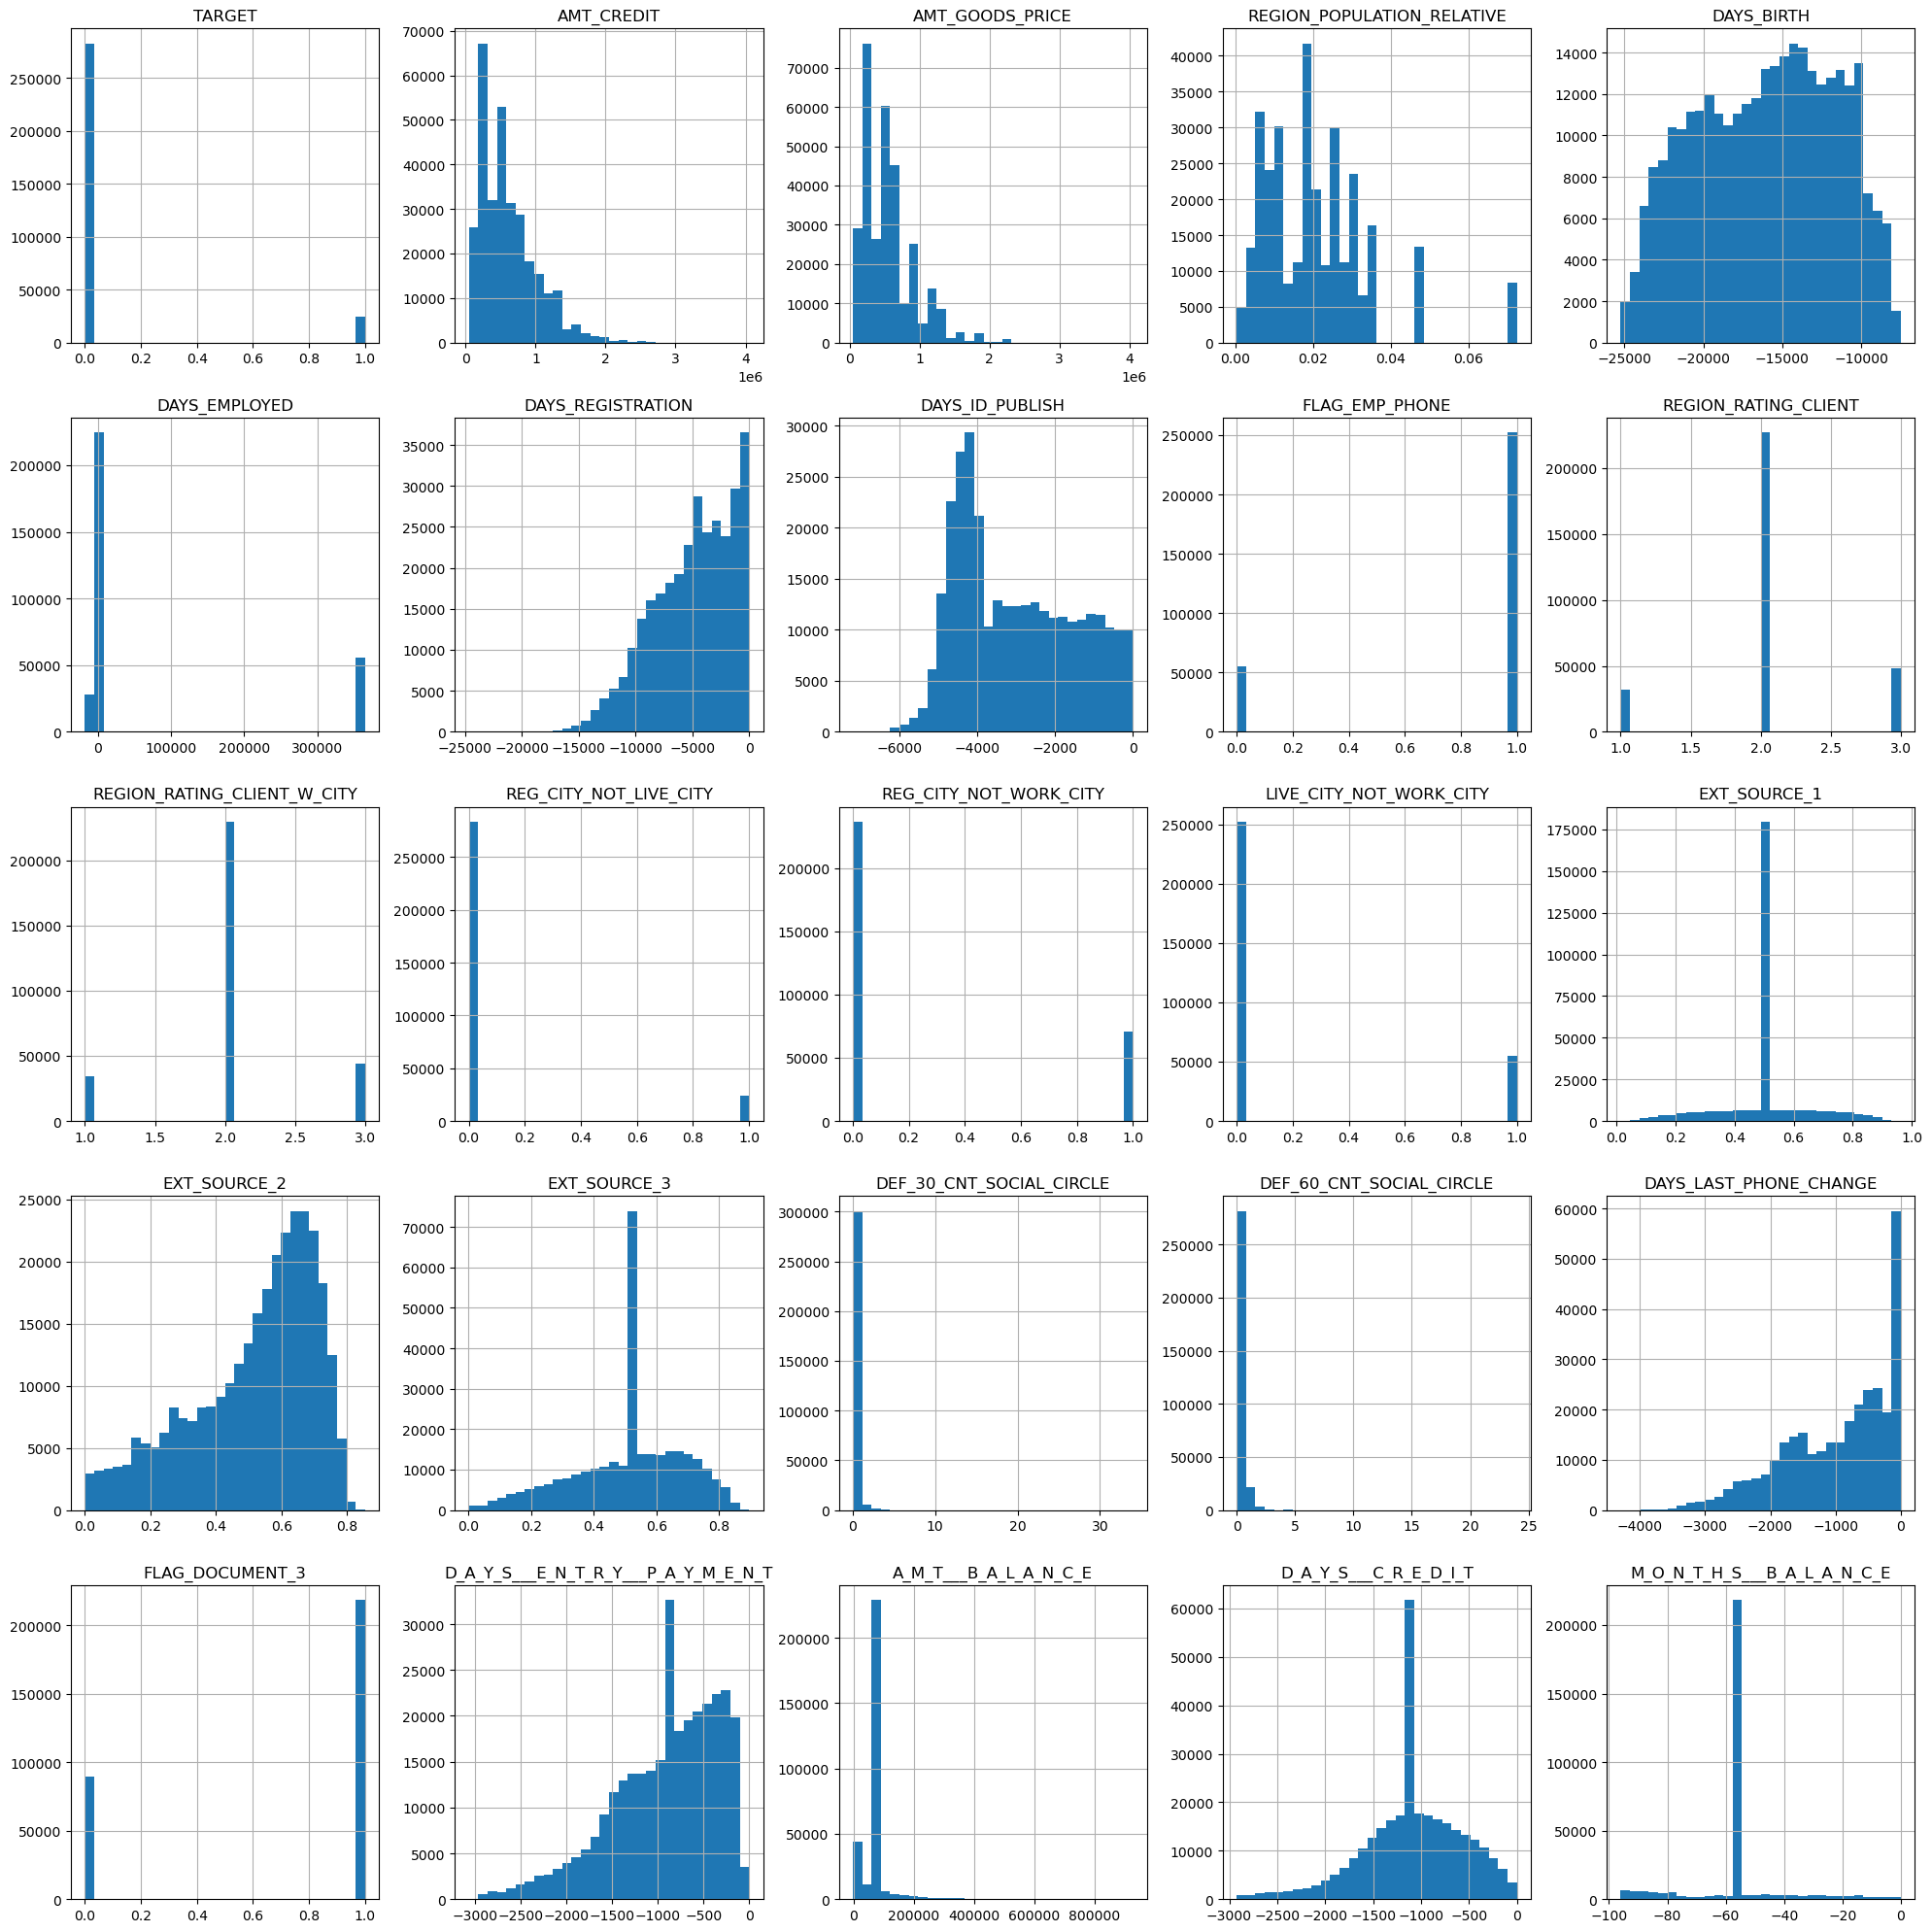

In [53]:
data.hist(figsize=(20,20), bins=30)
plt.tight_layout()
plt.show()

# BOXPLOT- TO FIND OUTLIERS

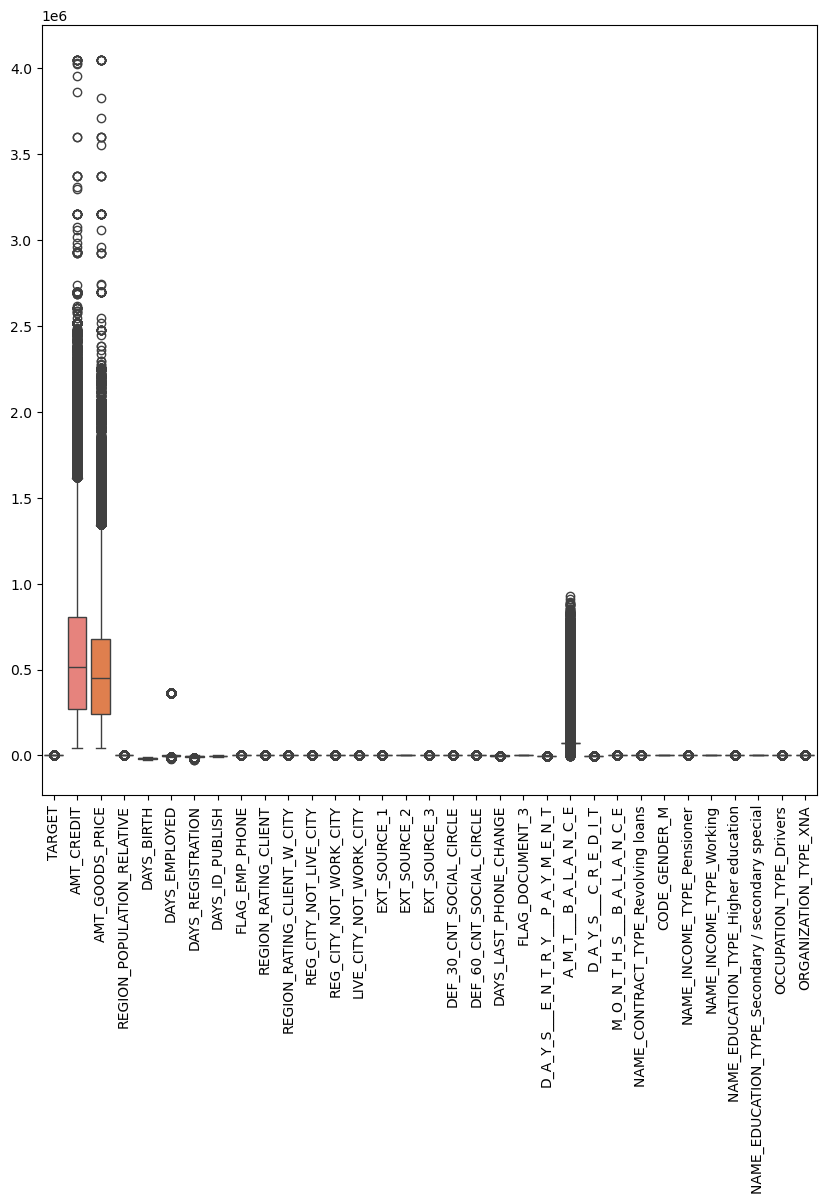

In [54]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [55]:
scaler=MinMaxScaler()
data[['A_M_T___B_A_L_A_N_C_E']]=scaler.fit_transform(data[['A_M_T___B_A_L_A_N_C_E']])

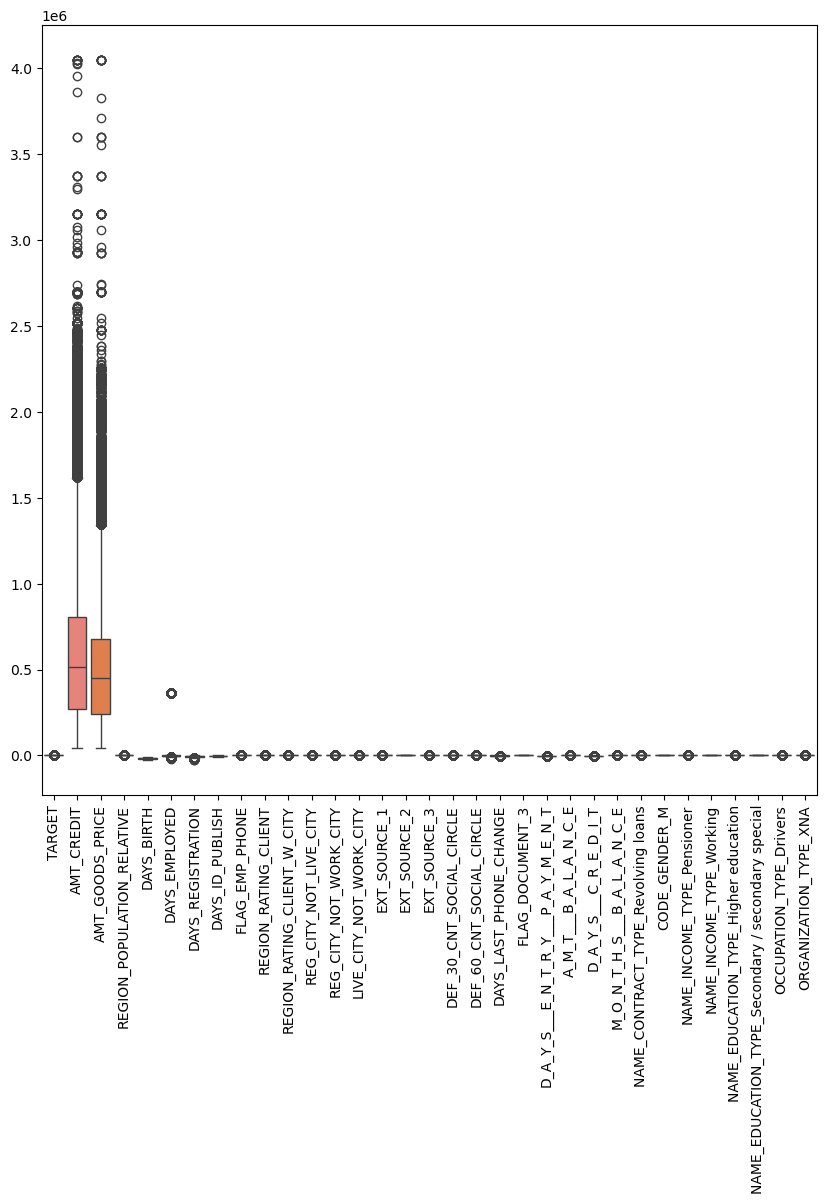

In [56]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

# HEATMAP-TO FIND HOW STRONGLY THE COLUMNS ARE CORELATED TO EACH OTHER

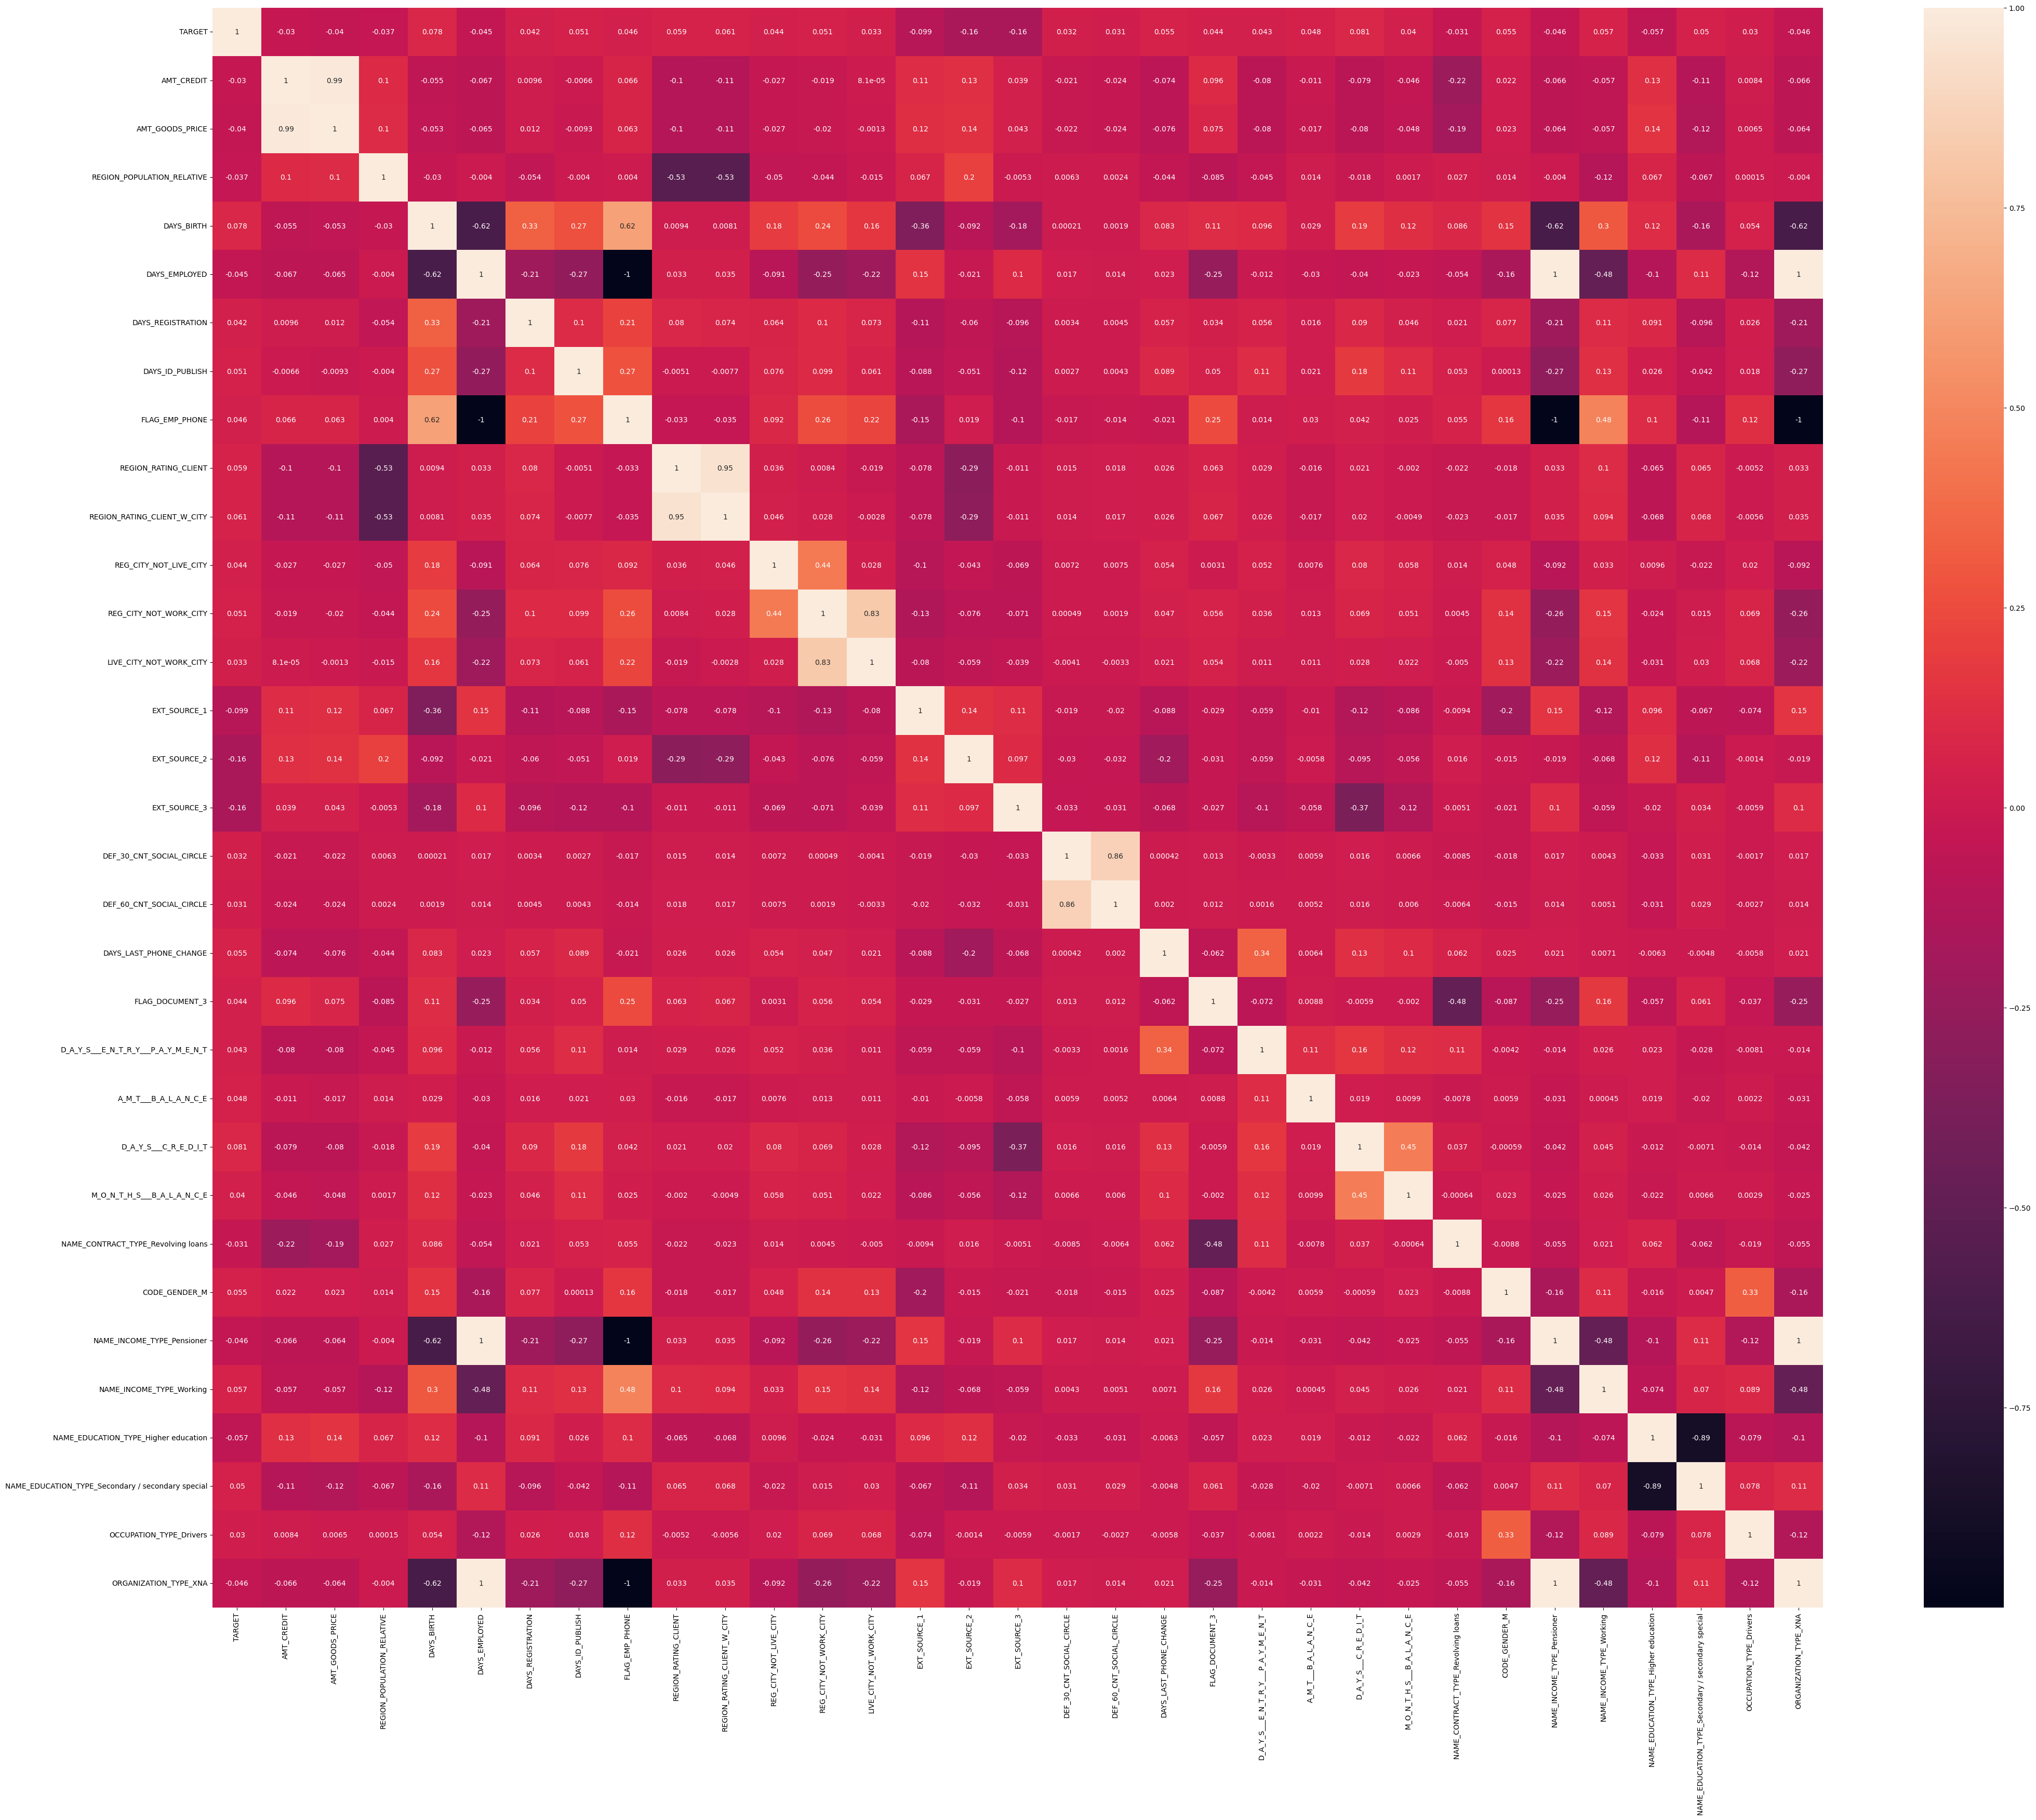

In [57]:
plt.figure(figsize=(50,40))
sns.heatmap(data.corr(),annot=True)
plt.show()

# PAIRPLOT- TO SHOW RELATION BETWEEN THE COLUMNS

In [63]:
#sns.pairplot(data)
#plt.show()

for i in data.columns:
    if i!='TARGET':
        plt.scatter(data[i],data['TARGET'])
        plt.xlabel(i)
        plt.ylabel('TARGET')
        plt.show()
        

ERROR! Session/line number was not unique in database. History logging moved to new session 341


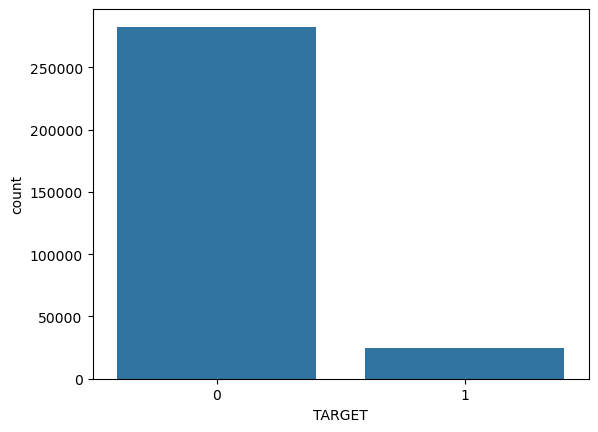

In [58]:
sns.countplot(x='TARGET', data=df)
plt.show()

## TRAIN/TEST SPLIT

In [59]:
data.shape

(307511, 33)

In [60]:
x=data.iloc[:,1:]
y=data.iloc[:,0]

In [61]:
x.head()

,AMT_CREDIT,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,...,D_A_Y_S___C_R_E_D_I_T,M_O_N_T_H_S___B_A_L_A_N_C_E,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Secondary / secondary special,OCCUPATION_TYPE_Drivers,ORGANIZATION_TYPE_XNA
0,406597.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,1,2,2,...,-874.00000,-47.000000,False,True,False,True,False,True,False,False
1,1293502.5,1129500.0,0.003541,-16765,-1188,-1186.0,-291,1,1,1,...,-1400.75000,-56.488946,False,False,False,False,True,False,False,False
2,135000.0,135000.0,0.010032,-19046,-225,-4260.0,-2531,1,2,2,...,-867.00000,-56.488946,True,True,False,True,False,True,False,False
3,312682.5,297000.0,0.008019,-19005,-3039,-9833.0,-2437,1,2,2,...,-1083.04711,-56.488946,False,False,False,True,False,True,False,False
4,513000.0,513000.0,0.028663,-19932,-3038,-4311.0,-3458,1,2,2,...,-1149.00000,-56.488946,False,True,False,True,False,True,False,False


In [62]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: TARGET, dtype: int64

## spliting training and testing data

In [67]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)

In [68]:
x_train.shape

(246008, 32)

In [69]:
y_train.shape

(246008,)

## model

## xgbclassifier

In [70]:
xgb=XGBClassifier()

In [71]:
xgb.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [72]:
y_predict=xgb.predict(x_test)


## random forest classifier

In [80]:
rf=RandomForestClassifier()

In [81]:
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
y_predict2=rf.predict(x_test)


## decision tree classifier

In [77]:
dt=DecisionTreeClassifier()

In [78]:
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [79]:
y_predict3=dt.predict(x_test)


## logistic regression

In [83]:
lr=LogisticRegression()

In [84]:
lr.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [85]:
y_predict4=lr.predict(x_test)

## model evaluation

## MODEL ACCURACY SCORE

In [86]:
print("XGBCLASSIFIER",accuracy_score(y_test, y_predict))
print("RANDOMFORESTCLASSIFIER",accuracy_score(y_test, y_predict2))
print("DECISIONTREECLASSIFIER",accuracy_score(y_test, y_predict3))
print("LOGISTICREGRESSION",accuracy_score(y_test, y_predict4))

XGBCLASSIFIER 0.918312927824659
RANDOMFORESTCLASSIFIER 0.91910963692828
DECISIONTREECLASSIFIER 0.8531128562834334
LOGISTICREGRESSION 0.9189958213420484


## CLASSIFICATION REPORT

In [87]:
print("XGBCLASSIFIER",classification_report(y_test, y_predict))
print("RANDOMFORESTCLASSIFIER",classification_report(y_test, y_predict2))
print("DECISIONTREECLASSIFIER",classification_report(y_test, y_predict3))
print("LOGISTICREGRESSION",classification_report(y_test, y_predict4))


XGBCLASSIFIER               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56521
           1       0.45      0.04      0.07      4982

    accuracy                           0.92     61503
   macro avg       0.68      0.52      0.51     61503
weighted avg       0.88      0.92      0.89     61503

RANDOMFORESTCLASSIFIER               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56521
           1       0.57      0.01      0.01      4982

    accuracy                           0.92     61503
   macro avg       0.74      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503

DECISIONTREECLASSIFIER               precision    recall  f1-score   support

           0       0.93      0.91      0.92     56521
           1       0.15      0.18      0.17      4982

    accuracy                           0.85     61503
   macro avg       0.54      0.55      0.54     61503
weighted avg  

#  Housing Loan Default Prediction

##  Project Overview
This project aims to predict whether a customer will default on a housing loan using machine learning techniques. It helps financial institutions reduce risk and make better lending decisions.

---

##  Dataset
- Financial and demographic data of customers
- Key features:
  - AMT_CREDIT
  - AMT_GOODS_PRICE
  - Income details
  - Employment data

---

## Challenges & Solutions

### Missing Values
- Handled using median (numerical) and mode (categorical).

---
###  Outliers
- Financial outliers were not removed because it removes the high valued customers also.
- Preserved high-value customer information.

---
## converting categorical into numerical values
-converted categorical columns into numerical columns inordered to fit into model.

---

## imported libraries
- Python
- Pandas, NumPy
- Scikit-learn
- XGBoost
- Matplotlib, Seaborn

---

## models Used
- Logistic Regression
- Random Forest
- XGBoost
- decision tree

  these algorithms are used because it is a classification problem.

---

##  Model Performance
- Accuracy: ~92%
- F1 Score: ~96%
- ROC-AUC used for evaluation

---

##  Key Insights
- Financial features are strong predictors
- Outliers represent real business cases
- Proper preprocessing improves performance

---
## Best model
-Among this RANDOMFORESTCLASSIFIER works with high accuracy.

---